# HW 03: Neural Networks

In this homework, you will learn how to apply Neural Networks model on your data for the purpose of multi-class classification.
The goal is to experience the phenomenon of overfitting.

In [ ]:
import tensorflow as tf
import pandas as pd 
import numpy as np 
import keras 
import keras.models as km 
import keras.layers as kl 
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from keras import losses
from keras import optimizers
from keras import metrics

## Introduction
In this project, you will be performing supervised learning or a classification technique. You can use a neural network, code from homework 3, or any other model you choose. You can perform binary or multi classification.
You can complete the project with your choice of data. Please return this jupyter notebook, the data you used (or a link to it that you used for automatic data download, and the powerpoint slides, clearly explaining all the choices you made from start to finish.

## Selecting data and pre-processing
Select any data suitable for your algorithm. For instance, unlike the HW03 example, preferably select a dataset with numeric values or use data conversions (from categorical to numeric) carefully and reasonably.
Your data should have at least a thousand records. The number of features should generally be far smaller than the records, a nominal choice could be 10 features or less for thousand records. If your raw data has more features, you can do two things. 1. Use all features and ignore this rule. In this case, explain how it affects your generalizability. It will be seen in performance metrics. 2. Use popular feature selection techniques to reduce number of features. 

## strategy, model, and algorithm
The code provided here serves as a sample and is subject to change. Feel free to use pieces of code or simply write new algorithms.
Divide your data into training/validation/test sets. In the slides, explain what you did, random selection or otherwise and why. For example, did you use cross-validation or not and why.
Define your model, either nns or anything suitable for your project. If you use another model, explain in a sentence why you thought it's appropriate.
Mention what learning algorithm you used and what is the loss function.

## Finetuning, performance metrics, and plots
Here, you decide on selecting the right hyperparameters to improve performance. Epochs are an exmaple of this. As we saw in HW03, performance on the validation set can be used as a guide. The final model parameters you select, can be based on performance on validation set.
A more systematic way to improve results would be not to use the built-in function model.fit, but rather write a for loop for number of epochs and call other functions, such as model.train and model.eval, to observe performance on on training and validation sets, keeping track of the best performance as a final model. (We may go over an example of this in one of the next classes).

THE GOAL IS NOT TO DO TRIAL AND ERROR FOR INCREASING PERFORMANCE (DATA OVERFITTING, TEST SET SNOOPING) BUT RATHER HAVE A CONSISTENT STRATEGY WITH A SINGLE RUN OF EPOCHS. STRATEGY HAS MORE GRADE THAN YOUR FINAL PERFORMANCE.

Finally, mention which metrics you used to represent performance, error, F1 score, etc... Provide useful plots to explain your training and parameter selection (and previous runs, if useful).
Plots of performance or other useful visualization are recommended.
These plots help with crafting a concise conclusion on your classification/prediction project.

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 
  
# metadata 
print(car_evaluation.metadata) 
  
# variable information 
print(car_evaluation.variables) 

In [ ]:
y

In [ ]:
for col in X.select_dtypes(include='object').columns:
    X[col] = pd.Categorical(X[col]).codes 

In [ ]:
X

In [ ]:
y['class'] = pd.Categorical(y['class']).codes 

In [ ]:
y

In [ ]:
train_size=round(X.shape[0]*0.9)

In [ ]:
set(y['class'])

In [ ]:
len(set(y['class']))

In [ ]:

df_train_X = X[:train_size]
df_test_X = X[train_size:]


In [ ]:
df_train_X

In [ ]:
train_X = df_train_X.to_numpy()
test_X = df_test_X.to_numpy()

In [ ]:
train_X

In [ ]:
df_train_y = y[:train_size]
df_test_y = y[train_size:]

In [ ]:
train_y = df_train_y.to_numpy()
test_y = df_test_y.to_numpy()

In [ ]:
test_y

In [ ]:
from tensorflow.keras.utils import to_categorical

train_y = to_categorical(train_y, num_classes=len(set(y['class'])))
test_y = to_categorical(test_y, num_classes=len(set(y['class'])))

In [ ]:
train_y

In [ ]:
# input dim has to match input dimensions, here 6. Other parameters can be changed. See documentation on keras
model = km.Sequential() 
model.add(kl.Dense(20, 
                   input_dim = 6,
                   use_bias = True,
                   bias_initializer = "ones",
                   activation = "tanh",
                   kernel_initializer='glorot_uniform'))

In [ ]:
# I added an arbitrary layer
model.add(Dense(4,
                use_bias = True,
                bias_initializer = "ones",
                activation = "tanh")) 

In [ ]:
#output has four elements, since we have four categories to choose from
model.add(Dense(len(set(y['class'])), 
                use_bias = True, 
                bias_initializer = "ones", 
                activation = "softmax")) 

In [ ]:
# here, the loss function is what the model tries to minimize. 
model.compile(loss="categorical_crossentropy", optimizer = "rmsprop", metrics=["accuracy"]) 
#model.compile(loss="mse", optimizer = "rmsprop", metrics=["accuracy"]) 

In [ ]:
# the validation_data is NOT used to optimize training. It is only called validation to show history of performance on 
# the actual test set, in retrospect. We only use this here to observe trajectory of learning.
history=model.fit(train_X, train_y, 
                  batch_size=10, 
                  epochs = 100, 
                  verbose=1, 
                  validation_data=(test_X,test_y))

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [ ]:
model.evaluate(test_X,test_y)

In [ ]:
# performance look good
# however, let's look at the output
pred_y_continuous = model.predict(test_X)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
max_indices = np.argmax(pred_y_continuous, axis=1)

pred_y = np.zeros_like(pred_y_continuous, dtype=int)
pred_y[np.arange(pred_y_continuous.shape[0]), max_indices] = 1

In [ ]:
pred_y

In [ ]:
pred_y

In [ ]:
test_y

In [ ]:
# Performance
print(classification_report(test_y, pred_y))

In [ ]:
# answer the following and write appropriate code. Create as many cells you need.

**Kumbam Final Project Code**

In [1]:
#  Importing library and reading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("data_moods.csv")
df.head()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Thrisha Reddy\anaconda3\envs\ml\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Thrisha Reddy\anaconda3\envs\ml\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Thrisha Reddy\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Thrisha Reddy\AppData\Roaming\Python\Python310\site-packages\traitlets\config\application.py", line 

AttributeError: _ARRAY_API not found

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [2]:
# Droping columns
df = df.drop(columns=['name', 'album', 'artist', 'id', 'release_date'])

In [3]:
# Label encoding for categorial data
label_encoder = LabelEncoder()
df['mood_encoded'] = label_encoder.fit_transform(df['mood'])

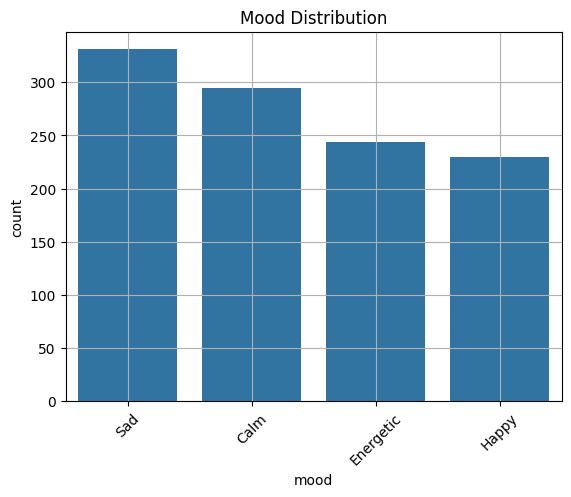

In [4]:
# Exploratory data analysis - hidden insights
# Mood distribution
sns.countplot(data=df, x='mood', order=df['mood'].value_counts().index)
plt.title("Mood Distribution")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

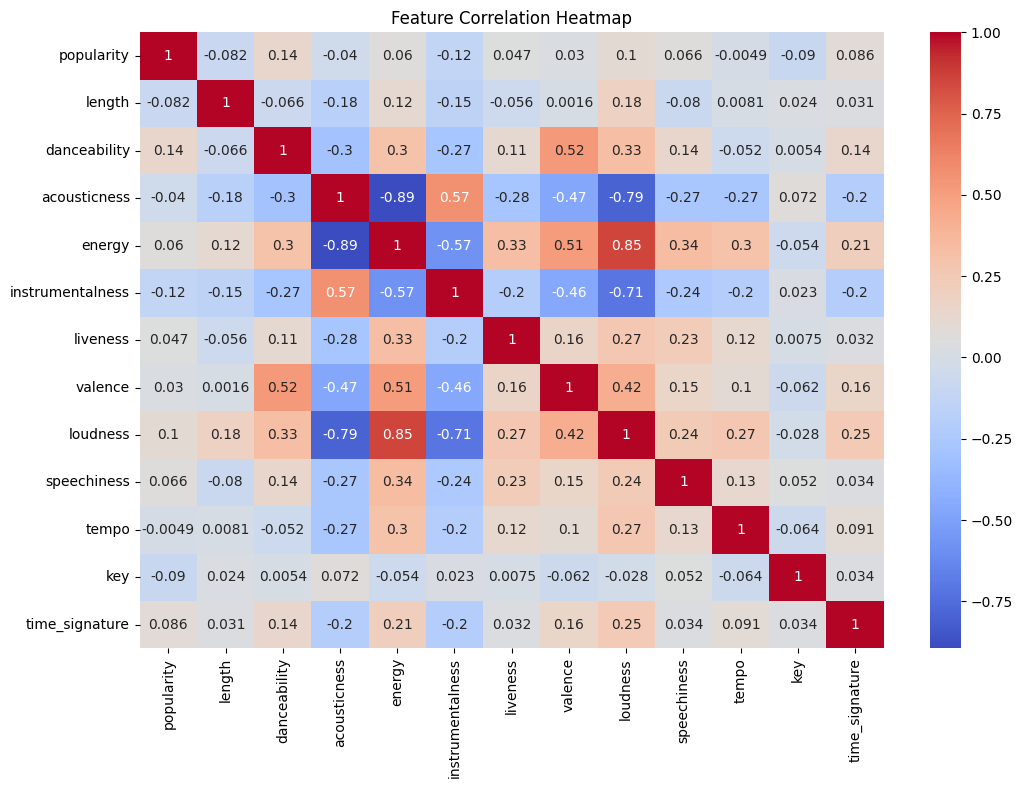

In [5]:

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['mood', 'mood_encoded']).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

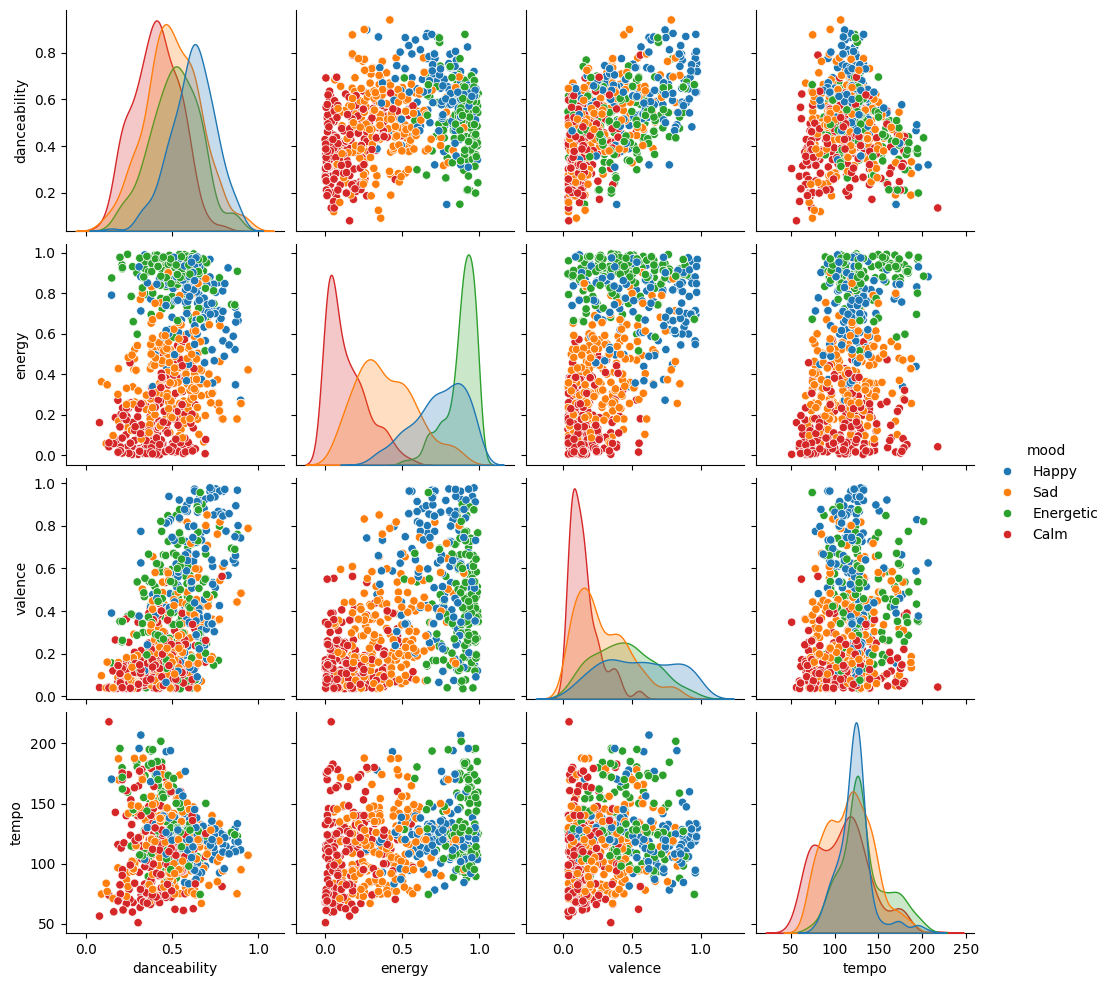

In [6]:
# Pairplot (subset of columns)
subset_cols = ['danceability', 'energy', 'valence', 'tempo', 'mood']
sns.pairplot(df[subset_cols], hue='mood')

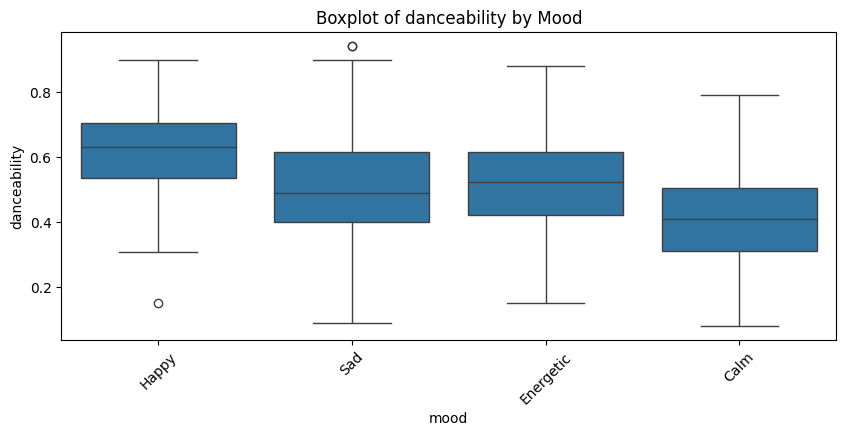

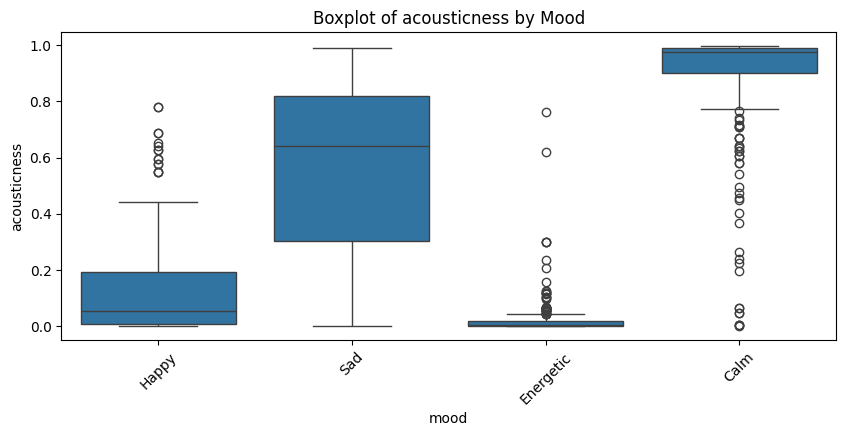

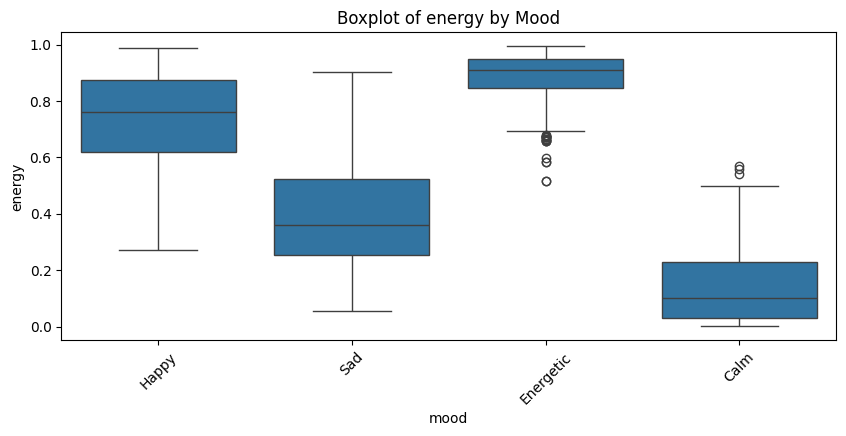

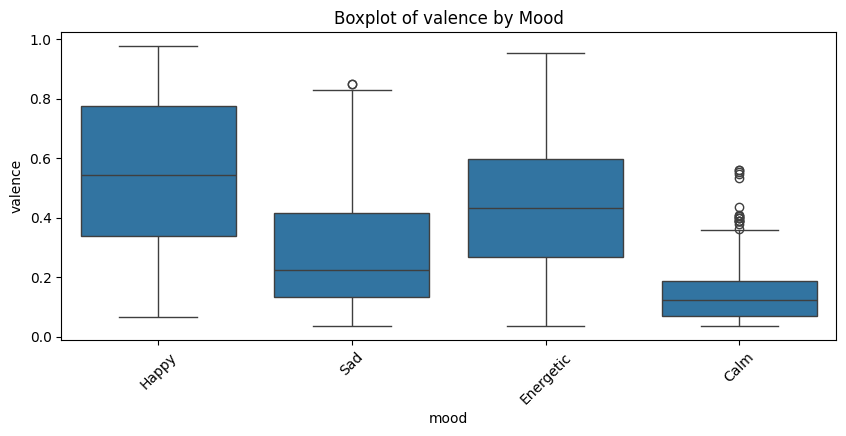

In [7]:
# Boxplots of selected features
for col in ['danceability', 'acousticness', 'energy', 'valence']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='mood', y=col, data=df)
    plt.title(f"Boxplot of {col} by Mood")
    plt.xticks(rotation=45)
    plt.show()


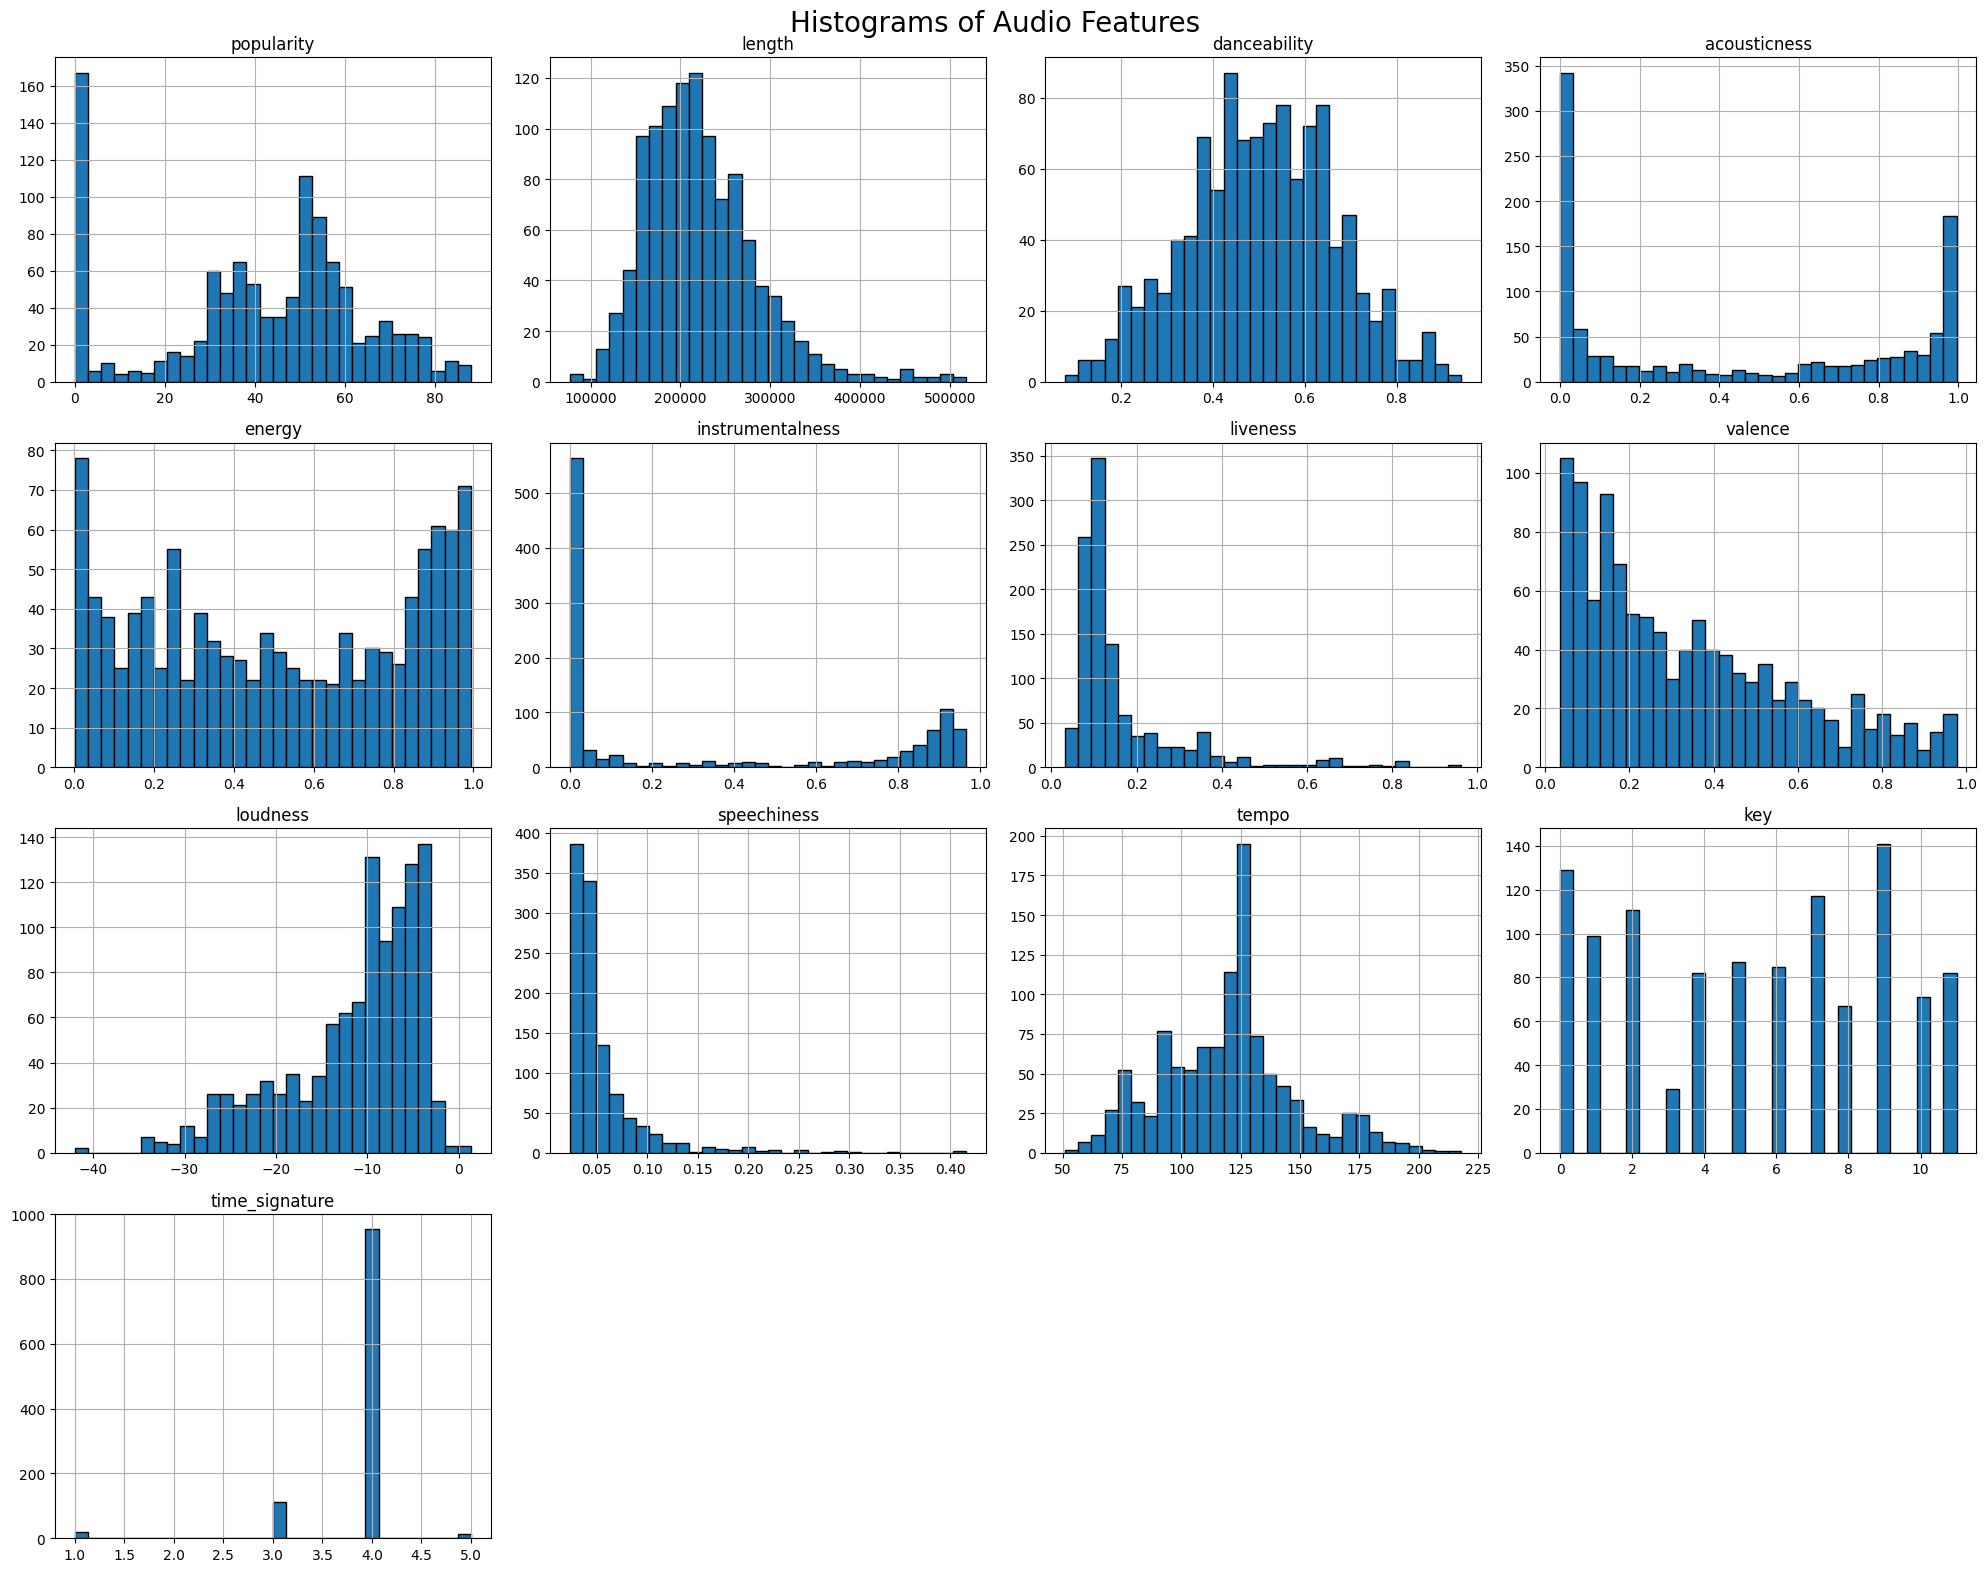

In [8]:
# Histograms of Audio Features
df.drop(columns=['mood', 'mood_encoded']).hist(figsize=(20, 16), bins=30, edgecolor='black')
plt.suptitle('Histograms of Audio Features', fontsize=20)
plt.tight_layout()
plt.show()

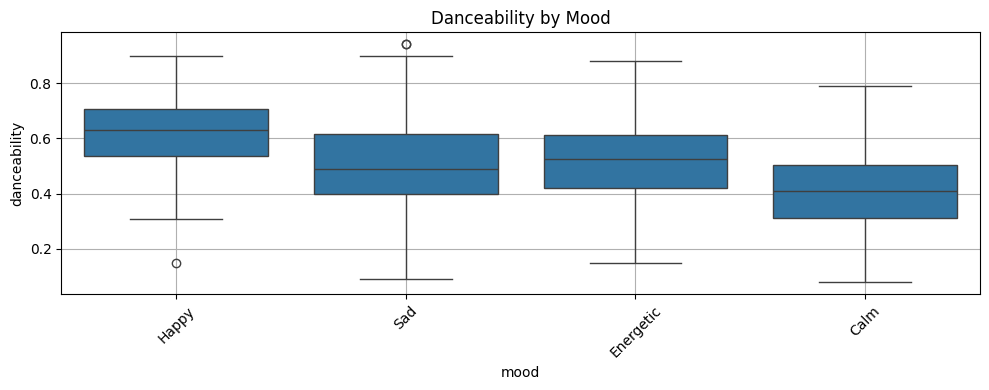

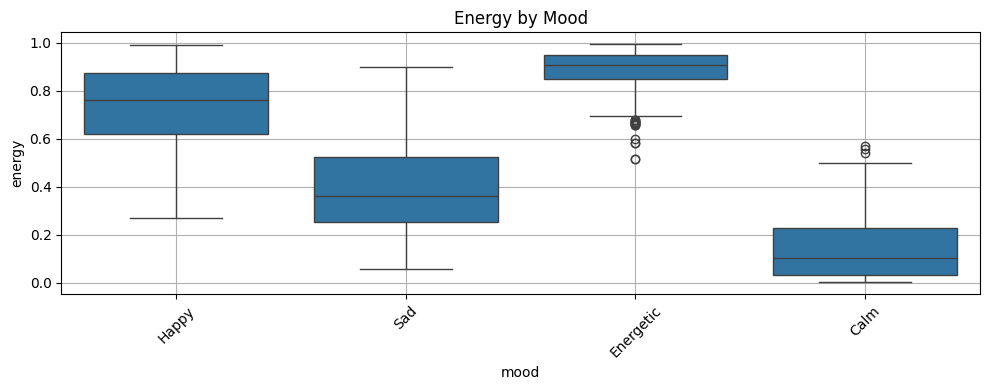

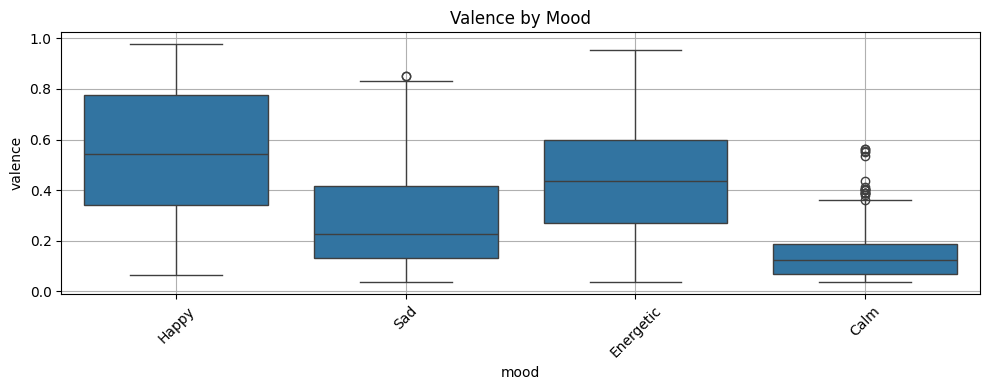

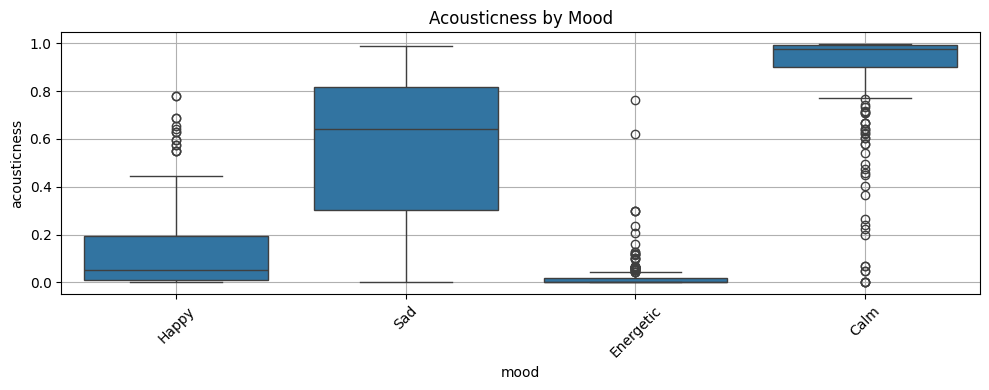

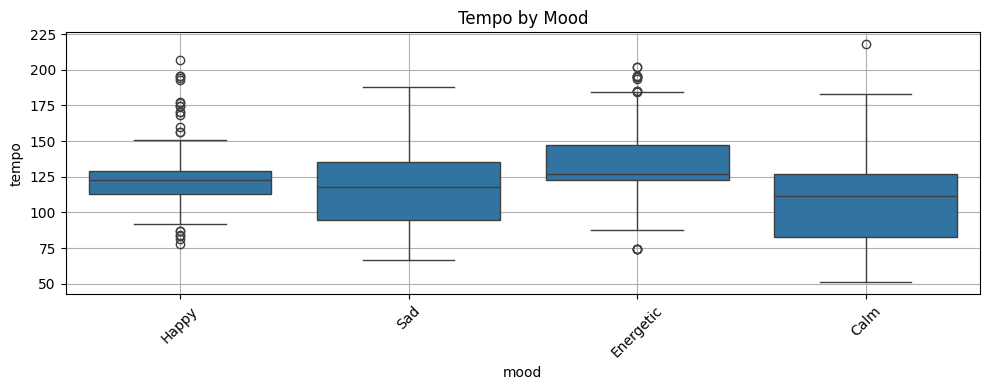

In [9]:
# Boxplots for the features with mood column
features = ['danceability', 'energy', 'valence', 'acousticness', 'tempo']
for col in features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='mood', y=col, data=df)
    plt.title(f"{col.capitalize()} by Mood")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

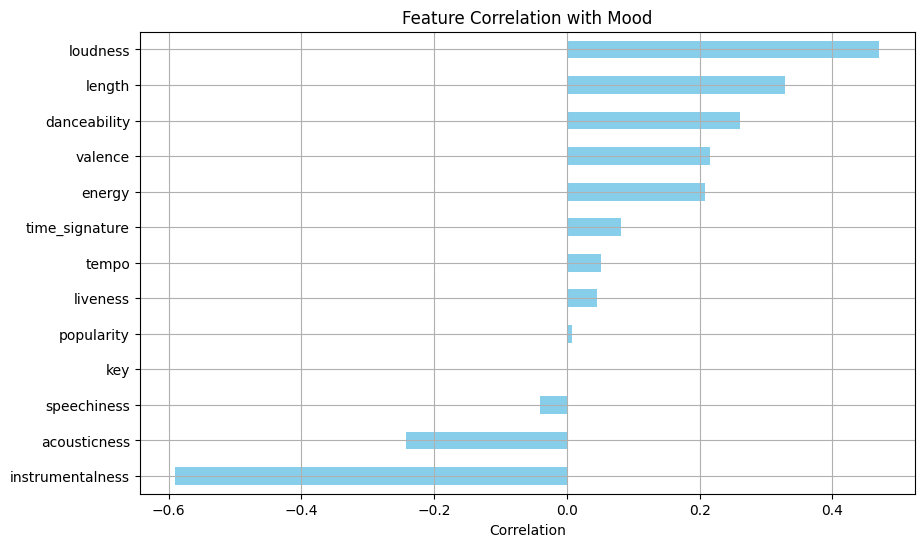

In [10]:
# Feature Correlation with Mood
df_corr = df.copy()
df_corr['mood_numeric'] = label_encoder.transform(df_corr['mood'])

df_corr_numeric = df_corr.select_dtypes(include=[np.number])

corr_target = df_corr_numeric.corr()['mood_numeric'].drop(['mood_numeric', 'mood_encoded'])

corr_target.sort_values().plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title("Feature Correlation with Mood")
plt.xlabel("Correlation")
plt.grid(True)
plt.show()

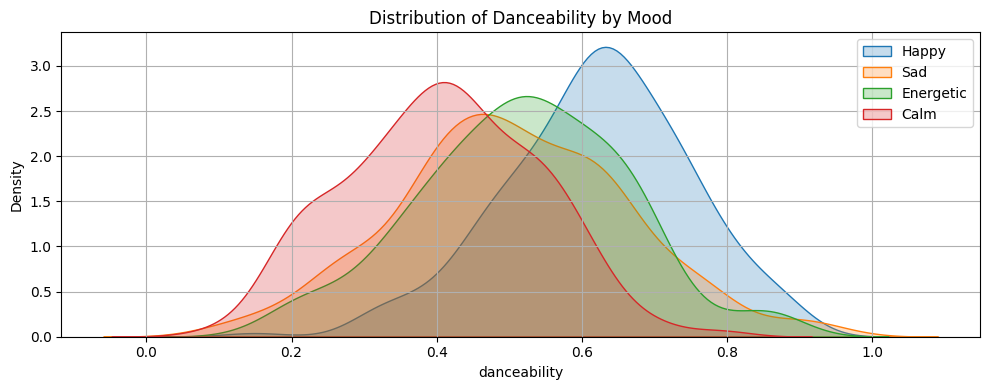

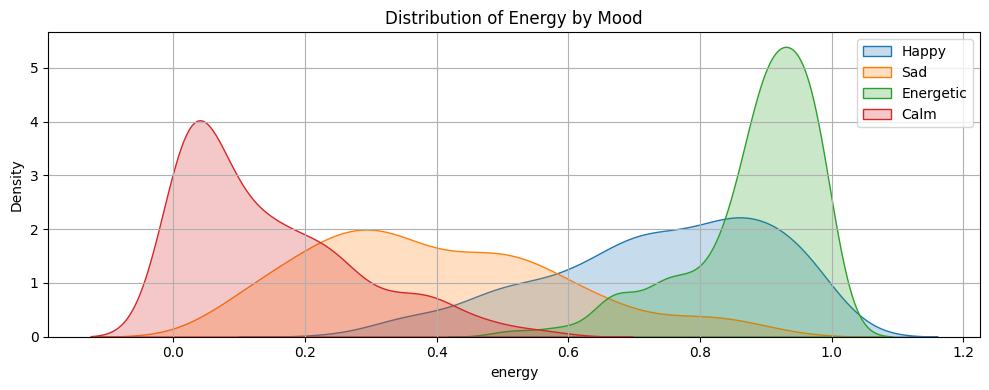

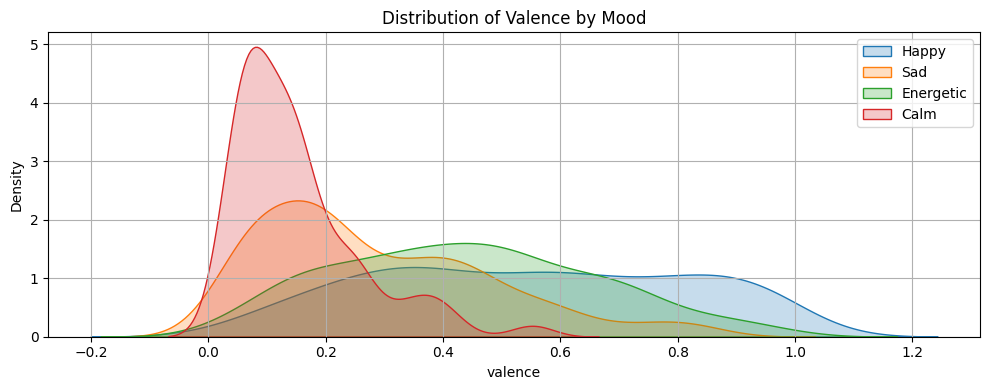

In [11]:
# Distribution of danceability, energy, valence by Mood
kde_features = ['danceability', 'energy', 'valence']
for feature in kde_features:
    plt.figure(figsize=(10, 4))
    for mood in df['mood'].unique():
        sns.kdeplot(df[df['mood'] == mood][feature], label=mood, fill=True)
    plt.title(f"Distribution of {feature.capitalize()} by Mood")
    plt.xlabel(feature)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

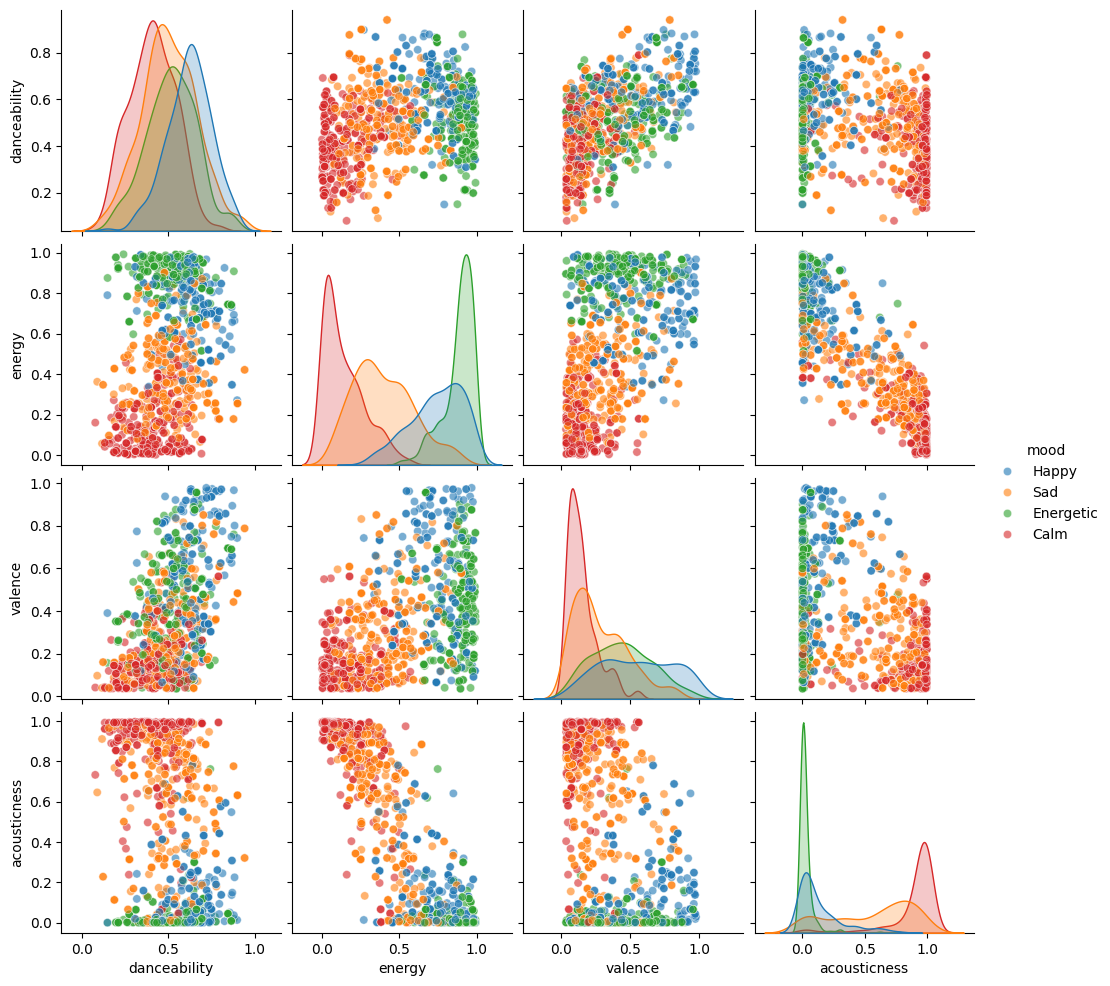

In [12]:
# pairplots for selected featured with mood
selected = ['danceability', 'energy', 'valence', 'acousticness', 'mood']
sns.pairplot(df[selected], hue='mood', plot_kws={'alpha': 0.6})

In [13]:
# summary of the column mood
summary_stats = df.groupby('mood').agg(['mean', 'std']).T
summary_stats.head(10)

mood                        Calm      Energetic          Happy            Sad
popularity   mean      39.345763      41.192623      48.656522      38.283988
             std       14.370550      23.536151      26.154885      25.925377
length       mean  193956.962712  216271.774590  230043.052174  248069.951662
             std    61485.490991   53617.625336   52320.449865   67090.797818
danceability mean       0.407556       0.517959       0.619804       0.503747
             std        0.132171       0.143632       0.128109       0.159533
acousticness mean       0.892061       0.026584       0.133157       0.553835
             std        0.201070       0.076183       0.176610       0.323130
energy       mean       0.143393       0.881799       0.739204       0.397325
             std        0.131820       0.097280       0.169940       0.193995

In [14]:
# Spliting the input and output into X and y
X = df.drop(columns=['mood', 'mood_encoded'])
y = df['mood_encoded']

In [15]:
# Spliting the dataset into training, testing and validation data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [16]:
# Apllying the Standard scaler for same reange of values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [17]:
# Converting the output into categorical format
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)
y_test_cat = to_categorical(y_test)


In [18]:
# Buiding basic NN model tensorflow 
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(y_train_cat.shape[1], activation='softmax')
])


C:\Users\Thrisha Reddy\anaconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Creating the loss function and optimizer for training and validation data
loss_fn = tf.keras.losses.CategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam()

train_acc_metric = tf.keras.metrics.CategoricalAccuracy()
val_acc_metric = tf.keras.metrics.CategoricalAccuracy()

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_cat)).shuffle(1000).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_cat)).batch(32)

In [20]:
# Performing the training with 20 epoches
train_loss_results, val_loss_results = [], []
train_acc_results, val_acc_results = [], []

for epoch in range(20):
    epoch_loss_avg = tf.keras.metrics.Mean()
    val_epoch_loss_avg = tf.keras.metrics.Mean()
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()

    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss_value = loss_fn(y_batch, logits)
        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
        epoch_loss_avg.update_state(loss_value)
        train_acc_metric.update_state(y_batch, logits)

    for x_batch_val, y_batch_val in val_ds:
        val_logits = model(x_batch_val, training=False)
        val_loss = loss_fn(y_batch_val, val_logits)
        val_epoch_loss_avg.update_state(val_loss)
        val_acc_metric.update_state(y_batch_val, val_logits)

    train_loss_results.append(epoch_loss_avg.result().numpy())
    val_loss_results.append(val_epoch_loss_avg.result().numpy())
    train_acc_results.append(train_acc_metric.result().numpy())
    val_acc_results.append(val_acc_metric.result().numpy())

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {train_loss_results[-1]:.4f}, Train Acc = {train_acc_results[-1]:.4f}, "
          f"Val Loss = {val_loss_results[-1]:.4f}, Val Acc = {val_acc_results[-1]:.4f}")


Epoch 1: Train Loss = 1.2986, Train Acc = 0.4169, Val Loss = 1.1565, Val Acc = 0.5576
Epoch 2: Train Loss = 1.0192, Train Acc = 0.6065, Val Loss = 0.9179, Val Acc = 0.6061
Epoch 3: Train Loss = 0.8273, Train Acc = 0.6922, Val Loss = 0.7306, Val Acc = 0.6909
Epoch 4: Train Loss = 0.6941, Train Acc = 0.7390, Val Loss = 0.6114, Val Acc = 0.7515
Epoch 5: Train Loss = 0.6027, Train Acc = 0.7649, Val Loss = 0.5296, Val Acc = 0.7939
Epoch 6: Train Loss = 0.5637, Train Acc = 0.7688, Val Loss = 0.4758, Val Acc = 0.8121
Epoch 7: Train Loss = 0.4886, Train Acc = 0.7961, Val Loss = 0.4429, Val Acc = 0.7939
Epoch 8: Train Loss = 0.4672, Train Acc = 0.8065, Val Loss = 0.4198, Val Acc = 0.8182
Epoch 9: Train Loss = 0.4298, Train Acc = 0.8195, Val Loss = 0.3962, Val Acc = 0.8303
Epoch 10: Train Loss = 0.4465, Train Acc = 0.7961, Val Loss = 0.3837, Val Acc = 0.8303
Epoch 11: Train Loss = 0.4730, Train Acc = 0.8156, Val Loss = 0.3797, Val Acc = 0.8424
Epoch 12: Train Loss = 0.4134, Train Acc = 0.8130, V

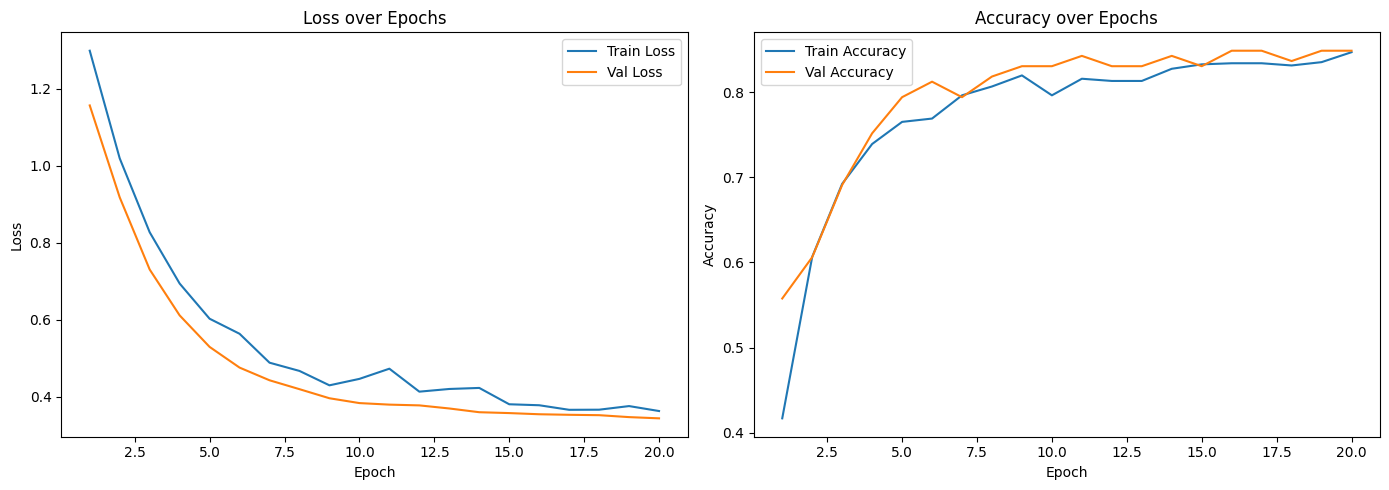

In [21]:
# plotting the curved of loss and Accuracy for every epoch
epochs = range(1, 21)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_results, label='Train Loss')
plt.plot(epochs, val_loss_results, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_results, label='Train Accuracy')
plt.plot(epochs, val_acc_results, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")
plt.tight_layout()
plt.show()


In [22]:
# Model 2 with depper and more layer NN for comparsion
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train_cat.shape[1], activation='softmax')
])


In [23]:
# Creating the loss function and optimizer for training and validation data for model 2
loss_fn2 = tf.keras.losses.CategoricalCrossentropy()
optimizer2 = tf.keras.optimizers.Adam()

train_acc_metric2 = tf.keras.metrics.CategoricalAccuracy()
val_acc_metric2 = tf.keras.metrics.CategoricalAccuracy()

train_ds2 = tf.data.Dataset.from_tensor_slices((X_train, y_train_cat)).shuffle(1000).batch(32)
val_ds2 = tf.data.Dataset.from_tensor_slices((X_val, y_val_cat)).batch(32)


In [24]:
# Performing the training with 20 epoches for model 2
train_loss_results2, val_loss_results2 = [], []
train_acc_results2, val_acc_results2 = [], []

for epoch in range(20):
    epoch_loss_avg = tf.keras.metrics.Mean()
    val_epoch_loss_avg = tf.keras.metrics.Mean()
    train_acc_metric2.reset_state()
    val_acc_metric2.reset_state()

    for x_batch, y_batch in train_ds2:
        with tf.GradientTape() as tape:
            logits = model2(x_batch, training=True)
            loss_value = loss_fn2(y_batch, logits)
        grads = tape.gradient(loss_value, model2.trainable_weights)
        optimizer2.apply_gradients(zip(grads, model2.trainable_weights))
        epoch_loss_avg.update_state(loss_value)
        train_acc_metric2.update_state(y_batch, logits)

    for x_batch_val, y_batch_val in val_ds2:
        val_logits = model2(x_batch_val, training=False)
        val_loss = loss_fn2(y_batch_val, val_logits)
        val_epoch_loss_avg.update_state(val_loss)
        val_acc_metric2.update_state(y_batch_val, val_logits)

    train_loss_results2.append(epoch_loss_avg.result().numpy())
    val_loss_results2.append(val_epoch_loss_avg.result().numpy())
    train_acc_results2.append(train_acc_metric2.result().numpy())
    val_acc_results2.append(val_acc_metric2.result().numpy())

    print(f"Model 2 - Epoch {epoch+1}: "
          f"Train Loss = {train_loss_results2[-1]:.4f}, Train Acc = {train_acc_results2[-1]:.4f}, "
          f"Val Loss = {val_loss_results2[-1]:.4f}, Val Acc = {val_acc_results2[-1]:.4f}")


Model 2 - Epoch 1: Train Loss = 0.9067, Train Acc = 0.6558, Val Loss = 0.5316, Val Acc = 0.8000
Model 2 - Epoch 2: Train Loss = 0.4707, Train Acc = 0.7870, Val Loss = 0.3981, Val Acc = 0.8061
Model 2 - Epoch 3: Train Loss = 0.3888, Train Acc = 0.8390, Val Loss = 0.3688, Val Acc = 0.8485
Model 2 - Epoch 4: Train Loss = 0.3628, Train Acc = 0.8260, Val Loss = 0.3483, Val Acc = 0.8545
Model 2 - Epoch 5: Train Loss = 0.3146, Train Acc = 0.8636, Val Loss = 0.3012, Val Acc = 0.8606
Model 2 - Epoch 6: Train Loss = 0.2737, Train Acc = 0.8948, Val Loss = 0.2898, Val Acc = 0.8545
Model 2 - Epoch 7: Train Loss = 0.2447, Train Acc = 0.9104, Val Loss = 0.3194, Val Acc = 0.8606
Model 2 - Epoch 8: Train Loss = 0.2295, Train Acc = 0.9052, Val Loss = 0.3034, Val Acc = 0.8667
Model 2 - Epoch 9: Train Loss = 0.2242, Train Acc = 0.9117, Val Loss = 0.2821, Val Acc = 0.8667
Model 2 - Epoch 10: Train Loss = 0.1945, Train Acc = 0.9325, Val Loss = 0.2803, Val Acc = 0.8667
Model 2 - Epoch 11: Train Loss = 0.1776

In [25]:
# Finding the best model based on the validation accuracy
best_model = model if val_acc_results[-1] > val_acc_results2[-1] else model2
print("Best Model Selected Based on Final Validation Accuracy.")


Best Model Selected Based on Final Validation Accuracy.


In [26]:
# classification report with best model
y_pred_test = best_model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

        Calm       0.98      0.93      0.95        45
   Energetic       0.88      0.83      0.86        36
       Happy       0.79      0.89      0.84        35
         Sad       0.94      0.94      0.94        49

    accuracy                           0.90       165
   macro avg       0.90      0.90      0.90       165
weighted avg       0.91      0.90      0.90       165



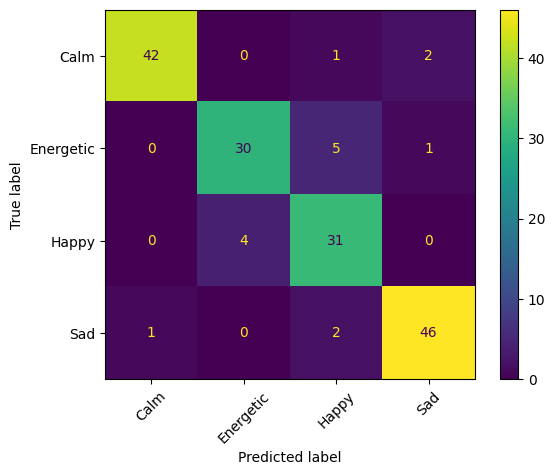

In [27]:
# confusion matrix with best model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=label_encoder.classes_, xticks_rotation=45)

### Final Observations & Learning
A manual neural network was successfully trained on mood classification using GradientTape.
Rich feature engineering and EDA revealed clear signal in audio features like energy, valence, and danceability.
The classification report confirms balanced performance across classes.
This pipeline is reusable for any music emotion analysis project using numerical audio descriptors.

In [ ]:
# did performnace improve? --full grade is not related to higher performance but clarity of code and comments and discussion